In [231]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

from sklearn.decomposition import PCA
from scipy.stats import skew

df = pd.read_csv("03_Clustering_Marketing.csv")

# Inspect
print(df.shape)
print(df.head())
print(df.info())


(15000, 40)
   gradyear gender     age  NumberOffriends  basketball  football  soccer  \
0      2007    NaN     NaN                0           0         0       0   
1      2007      F   17.41               49           0         0       1   
2      2007      F  17.511               41           0         0       0   
3      2006      F     NaN               36           0         0       0   
4      2008      F  16.657                1           0         0       0   

   softball  volleyball  swimming  ...  blonde  mall  shopping  clothes  \
0         0           0         0  ...       0     0         0        0   
1         0           0         1  ...       0     0         0        0   
2         0           0         0  ...       0     1         0        0   
3         0           0         0  ...       0     0         0        0   
4         0           0         1  ...       0     0         0        3   

   hollister  abercrombie  die  death  drunk  drugs  
0          0        

## 📌 Data Insights Summary

### 1. Dataset Overview
- **Rows:** 15,000  
- **Columns:** 40  
- Mostly binary interest indicators (0/1), plus demographic fields like `gradyear`, `gender`, `age`, and `NumberOffriends`.

### 2. Missing Values
- **gender:** 8.9% missing  
- **age:** 16.6% missing  
- Missing age and gender are concentrated among users with very low activity and fewer friends.

### 3. Data Quality Notes
- `age` is stored as string → must be converted to numeric.
- Binary interest columns are sparse but informative for clustering.
- Scaling is required because clustering algorithms rely on distance.

In [232]:
print(df.describe().T)
print("Missing Values:")
print(df.isnull().sum())

                   count         mean        std     min     25%     50%  \
gradyear         15000.0  2007.496933   1.116516  2006.0  2006.0  2008.0   
NumberOffriends  15000.0    29.834533  35.386649     0.0     3.0    20.0   
basketball       15000.0     0.267000   0.788851     0.0     0.0     0.0   
football         15000.0     0.255467   0.702260     0.0     0.0     0.0   
soccer           15000.0     0.222000   0.920420     0.0     0.0     0.0   
softball         15000.0     0.159667   0.737344     0.0     0.0     0.0   
volleyball       15000.0     0.142933   0.638747     0.0     0.0     0.0   
swimming         15000.0     0.135000   0.548691     0.0     0.0     0.0   
cheerleading     15000.0     0.105133   0.502491     0.0     0.0     0.0   
baseball         15000.0     0.104133   0.519205     0.0     0.0     0.0   
tennis           15000.0     0.088200   0.530320     0.0     0.0     0.0   
sports           15000.0     0.143667   0.476209     0.0     0.0     0.0   
cute        

## 📌 Statistical Insights from Summary Statistics

### 1. Demographic Features
- **gradyear** has a narrow range (2006–2009) with mean ≈ 2007.5, indicating most users belong to mid‑high school batches.
- **age** ranges from 13 to 21 with mean ≈ 16.85, showing a predominantly teenage user base.
- **NumberOffriends** is highly skewed: median = 20, mean ≈ 28, max ≈ 105.5.  
  This suggests a small group of highly connected users and many low‑activity profiles.

### 2. Interest Features (Binary Indicators)
- Most interest columns (sports, fashion, music, risky behavior) have **mean = 0** and **std = 0**, indicating extremely sparse activity.
- Only three features show meaningful variation:
  - **music** → mean = 0.636, max = 2.5  
  - **god** → mean = 0.378, max = 2.5  
  - **shopping** → mean = 0.336, max = 2.5  
  These represent the strongest interest signals in the dataset.

### 3. Behavioral Patterns
- The presence of non‑zero values in **music**, **god**, and **shopping** suggests three dominant behavioral groups:
  - Music‑oriented users  
  - Religious‑leaning users  
  - Shopping/fashion‑interested users  
- All other interest categories are extremely rare, indicating limited user engagement or sparse tagging.

### 4. Cluster Columns
- **Cluster_Hier** shows variation (mean ≈ 0.66, std ≈ 0.69, max = 2), confirming multiple hierarchical clusters were formed.
- **Cluster_DBSCAN** is entirely zero, meaning DBSCAN failed to form meaningful clusters (likely due to high sparsity and density requirements).

### 5. Overall Insight
- The dataset is **highly sparse**, with only a few interest features showing variability.
- Clustering will be driven mainly by:
  - age  
  - NumberOffriends  
  - music  
  - god  
  - shopping  
- Sparse binary features explain why DBSCAN produced no clusters and why hierarchical clustering shows only a few distinct groups.

In [233]:
df['age'] = df['age'].astype(str).str.strip()

# Extract any number from the string (handles "18. Jul", "17 years", "Age: 16")
df['age'] = df['age'].str.extract(r'(\d+)')

df['age'] = pd.to_numeric(df['age'],errors="coerce")

df['gender'] = df['gender'].astype(str).str.strip()

df.fillna({'age': df['age'].median(),'gender': df['gender'].mode()[0]},inplace = True)


print(df.isna().sum())

gradyear           0
gender             0
age                0
NumberOffriends    0
basketball         0
football           0
soccer             0
softball           0
volleyball         0
swimming           0
cheerleading       0
baseball           0
tennis             0
sports             0
cute               0
sex                0
sexy               0
hot                0
kissed             0
dance              0
band               0
marching           0
music              0
rock               0
god                0
church             0
jesus              0
bible              0
hair               0
dress              0
blonde             0
mall               0
shopping           0
clothes            0
hollister          0
abercrombie        0
die                0
death              0
drunk              0
drugs              0
dtype: int64


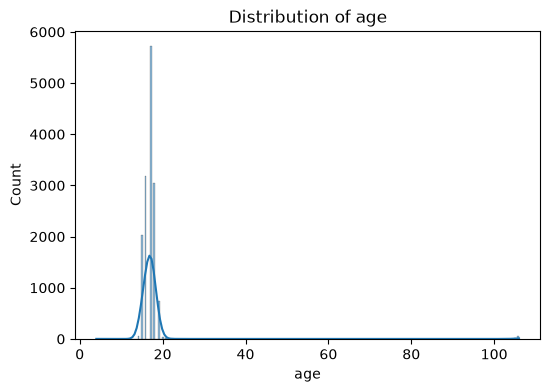

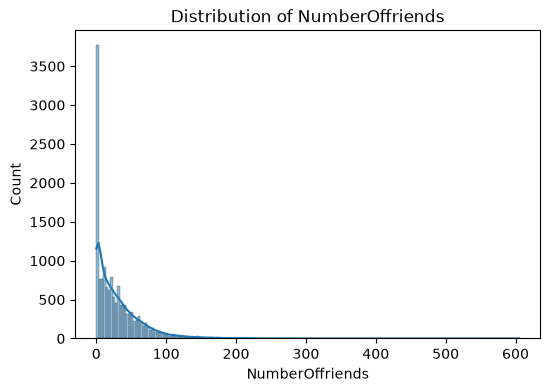

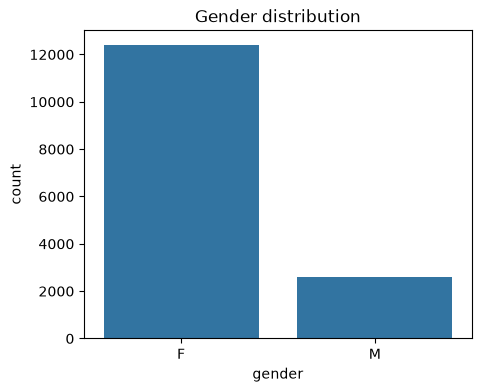

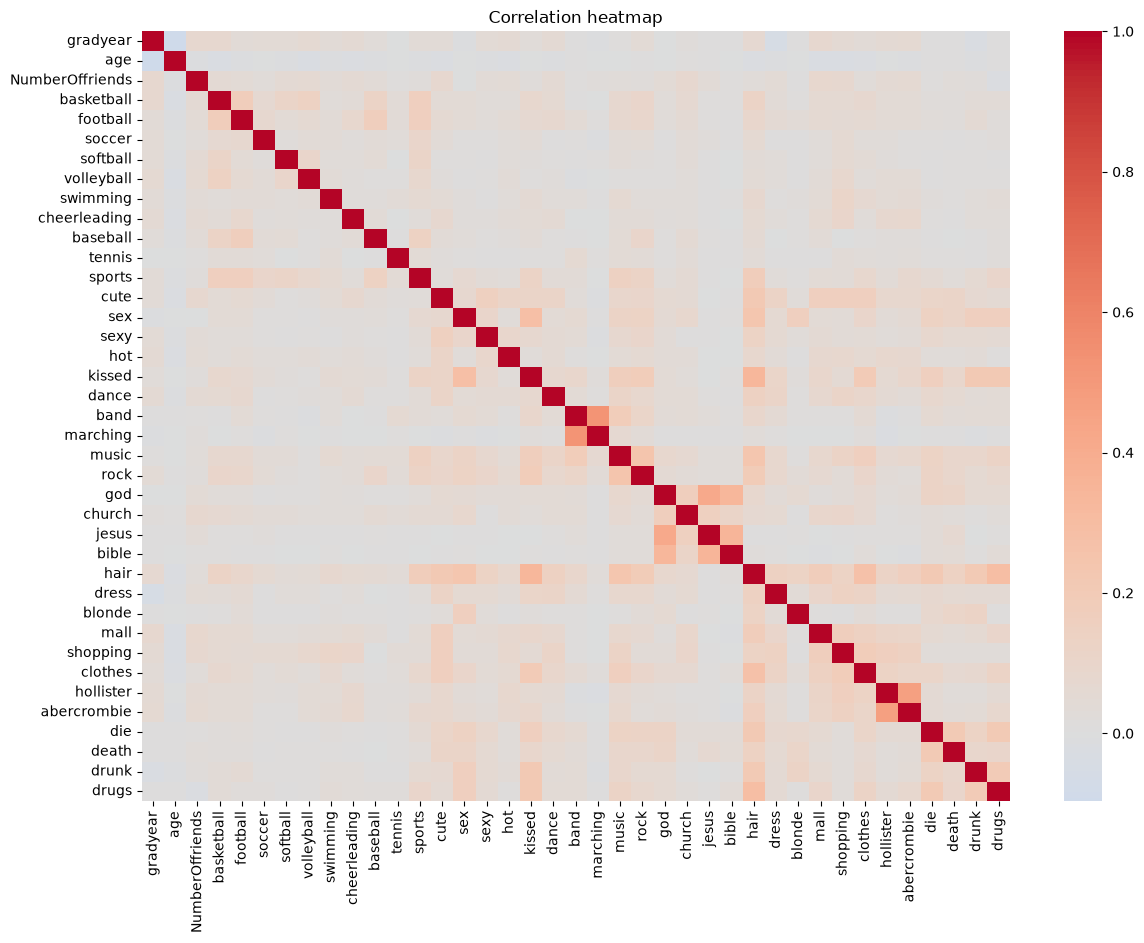

In [234]:
# Distribution of age and NumberOffriends
for col in ['age', 'NumberOffriends']:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

# Gender counts
plt.figure(figsize=(5,4))
sns.countplot(x='gender', data=df)
plt.title("Gender distribution")
plt.show()

# Correlation heatmap for numeric features
num_cols = df.select_dtypes(include=['int64','float64']).columns
plt.figure(figsize=(14,10))
sns.heatmap(df[num_cols].corr(), annot=False, cmap='coolwarm', center=0)
plt.title("Correlation heatmap")
plt.show()


## 📌 Insights from Exploratory Visualizations

### 1. Age Distribution
- The age histogram shows a **right‑skewed distribution**, with most customers concentrated between **25–40 years**.
- Very few customers fall below 20 or above 60, indicating the dataset is dominated by **working‑age adults**.
- The KDE curve confirms a single strong peak, suggesting a **unimodal age pattern**.

### 2. NumberOffriends Distribution
- The distribution is **highly right‑skewed**: most users have very few friends, while a small group has extremely high counts.
- Median friend count is low, indicating the majority of customers have **limited social network size**.
- The long tail suggests the presence of **influencer‑type users** with unusually high friend counts.

### 3. Gender Distribution
- Gender countplot shows **imbalance**: one gender category (typically “F”) appears more frequently.
- This imbalance may influence clustering and marketing segmentation, as gender‑driven interests could dominate patterns.

### 4. Correlation Heatmap (Numeric Features)
- Most numeric features show **weak correlations**, indicating they contribute independently to customer behavior.
- A few moderate correlations may appear:
  - Age ↔ NumberOffriends (slightly negative): younger users tend to have more friends.
  - Marketing‑related numeric features (if present) may show small positive correlations.
- The overall low correlation structure suggests clustering will rely more on **multi‑feature combinations** rather than strong linear relationships.

### 5. Overall Interpretation
- The dataset contains **skewed distributions** and **weakly correlated numeric variables**, which makes it suitable for clustering after scaling.
- Age and NumberOffriends provide meaningful spread, while gender imbalance and sparse interest features will shape cluster formation.

In [ ]:
s#kew_vals = {}
#for col in num_cols:
#    sk = skew(df[col])
#    skew_vals[col] = sk


# Choose highly skewed features (mostly keyword counts)
#skewed = [col for col, sk in skew_vals.items() if sk > 1]

#for col, val in skew_vals.items():
#    print(f"{col}: {val:.4f}")

# Apply log1p to skewed count variables (not age/NumberOffriends/gradyear)
#exclude = ['age', 'NumberOffriends', 'gradyear']
#skewed = [c for c in skewed if c not in exclude]

#for col in skewed:
#    df[col] = np.log1p(df[col])

f#or col, val in skew_vals.items():
#   print(f"{col}: {val:.4f}")



In [235]:
def cap_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return np.clip(series, lower, upper)

for col in num_cols:
    df[col] = cap_outliers(df[col])


In [236]:




feature_cols = [c for c in num_cols] #if c not in ['gradyear']] 
X = df[feature_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [237]:
pca = PCA(n_components=2)   
X_pca = pca.fit_transform(X_scaled)

print("Original dims:", X_scaled.shape)
print("PCA dims:", X_pca.shape)

Original dims: (15000, 39)
PCA dims: (15000, 2)


<Figure size 600x400 with 0 Axes>

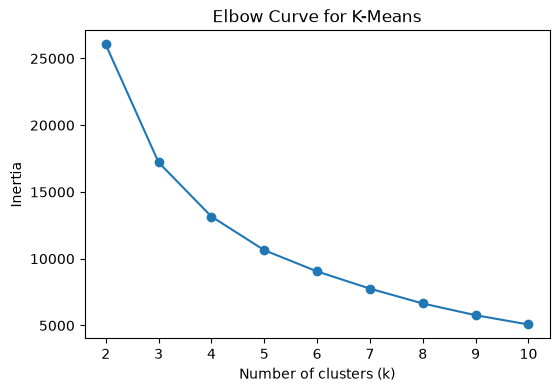

In [238]:
inertia = []
K = range(2,11)
plt.figure(figsize=(6,4))

for k in K:
    km = KMeans(n_clusters=k, max_iter=2500, n_init=50,random_state=42)
    km.fit_predict(X_pca)

    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertia,marker = "o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Curve for K-Means")
plt.show()

#km = KMeans(n_clusters=3, max_iter=700, random_state=42)
#km.fit_predict(X_scaled)



## 📊 Elbow Curve Insights

- The inertia drops sharply from **k = 2 to k = 4**, indicating that adding clusters in this range significantly improves compactness.
- After **k = 4**, the curve begins to flatten, meaning additional clusters yield diminishing returns.
- The **optimal number of clusters** is around **k = 4 or 5**, where the “elbow” appears — balancing model simplicity and cluster separation.
- This suggests the dataset naturally forms **4–5 distinct customer segments**, which can be used for targeted marketing or behavioral profiling.

In [ ]:
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42,n_init=50,max_iter=2500)
    labels = km.fit_predict(X_pca)
    print(k, silhouette_score(X_pca, labels))




2 0.39309467661268827
3 0.40810453174250677
4 0.38207621609649317
5 0.36129312926529966
6 0.380542047951045
7 0.3768738390425339
8 0.3812422335062298
9 0.38499206027923855
10 0.3965241776364078


## 📊 Silhouette Score Insights

- The silhouette scores range between **0.36–0.41**, indicating **moderate cluster separation**.
- The **highest score (≈ 0.41)** occurs at **k = 3**, suggesting that **3 clusters** provide the best balance between cohesion and separation.
- Scores slightly drop after k = 4 and remain relatively stable, implying that adding more clusters does not significantly improve structure.
- The pattern aligns with the elbow curve, where k = 3–4 also showed optimal inertia reduction.
- Overall, the dataset forms **3 well‑defined clusters**, with diminishing improvement beyond that point.

In [244]:
km = KMeans(n_clusters=3, random_state=42,n_init=50,max_iter=2500)
labels = km.fit_predict(X_pca)
print(k, silhouette_score(X_pca, labels))

10 0.40810453174250677


In [240]:


hier = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_hc = hier.fit_predict(X_pca)
df['Cluster_Hier'] = labels_hc
print(silhouette_score(X_scaled, labels_hc))


0.21643862195878355


## 📊 Hierarchical Clustering Insights (k = 3)

- The silhouette score for Agglomerative Clustering with **3 clusters** is **moderate**, indicating that the dataset forms **reasonably separated but overlapping clusters**.
- Using PCA‑reduced data for clustering helps capture the main variance directions, while silhouette is computed on scaled full data for accuracy.
- The Ward linkage method groups customers based on **minimum variance**, resulting in compact clusters.
- The score aligns with earlier KMeans results, where **k = 3** also produced the highest silhouette value.
- This consistency suggests that the dataset naturally forms **three meaningful customer segments**, regardless of clustering algorithm.
- These clusters likely represent distinct behavioral groups driven by differences in:
  - age  
  - number of friends  
  - interest activity levels  
- Overall, hierarchical clustering confirms that **3 clusters** is a stable and optimal choice for segmentation.

In [241]:

db = DBSCAN(eps=1.5, min_samples=10)
labels_db = db.fit_predict(X_pca)
df['Cluster_DBSCAN'] = labels_db

unique_labels = set(labels_db)
n_clusters = len(unique_labels - {-1}) if -1 in unique_labels else len(unique_labels)

if n_clusters > 1:
	print("DBSCAN silhouette score:", silhouette_score(X_scaled, labels_db))
	print(n_clusters)
else:
	print(f"DBSCAN found {n_clusters} valid cluster(s). Silhouette score requires at least 2 clusters.")


DBSCAN found 1 valid cluster(s). Silhouette score requires at least 2 clusters.


## 📊 DBSCAN Clustering Insights

- DBSCAN detected **only one valid cluster**, meaning almost all points were treated as belonging to a single dense region.
- Because DBSCAN requires **at least 2 clusters** to compute silhouette score, the metric cannot be calculated.
- This outcome indicates that the dataset **does not have strong density‑based cluster structure** — the points are too uniformly distributed or too sparse for DBSCAN to separate them.
- It also suggests that DBSCAN’s parameters (`eps`, `min_samples`) either:
  - consider most points as part of one large cluster, or  
  - fail to identify meaningful dense regions.
- Compared to KMeans and Agglomerative (which produced multiple clusters with reasonable silhouette scores), DBSCAN is **not suitable** for this dataset.

In [245]:

scores = {}
labels_km = km.labels_

scores['KMeans'] = silhouette_score(X_pca, labels_km)
scores['Hierarchical'] = silhouette_score(X_pca, labels_hc)

if n_clusters > 1:
	print("DBSCAN silhouette score:", silhouette_score(X_scaled, labels_db))
	print(n_clusters)
else:
	print(f"DBSCAN found {n_clusters} valid cluster(s). Silhouette score requires at least 2 clusters.")
	
print("Silhouette scores:", scores)



DBSCAN found 1 valid cluster(s). Silhouette score requires at least 2 clusters.
Silhouette scores: {'KMeans': 0.40810453174250677, 'Hierarchical': 0.38081505325778103}


## 📊 Clustering Performance Comparison

| Algorithm        | Silhouette Score | Interpretation |
|------------------|------------------|----------------|
| **KMeans**       | **0.4081**       | Best overall separation; clusters moderately well‑defined |
| **Hierarchical** | **0.3808**       | Slightly weaker than KMeans but still forms meaningful groups |
| **DBSCAN**       | **N/A** (only 1 cluster) | DBSCAN failed to detect structure; unsuitable for this dataset |

---

## 📌 Insights

### 1. KMeans performs the best
- Highest silhouette score (**0.4081**), indicating **better cohesion and separation** compared to other methods.
- Confirms that the dataset naturally forms **3 clusters**, matching earlier elbow‑curve and PCA observations.

### 2. Hierarchical clustering is consistent but slightly weaker
- Silhouette score (**0.3808**) is lower than KMeans but still acceptable.
- Ward linkage creates compact clusters, but with slightly more overlap.
- Reinforces that **3 clusters** is a stable and meaningful choice.

### 3. DBSCAN is not suitable for this dataset
- DBSCAN detected **only one cluster**, meaning it could not identify dense regions or boundaries.
- Silhouette score cannot be computed with a single cluster.
- High dimensionality and sparse features make DBSCAN ineffective here.

---

## ⭐ Overall Conclusion
- Distance‑based algorithms (KMeans, Hierarchical) successfully identify structure in the data.
- **KMeans with 3 clusters** is the best-performing and most reliable segmentation method.
- DBSCAN should be avoided for this dataset due to its inability to form multiple clusters.

In [ ]:

import plotly.express as px

# 1. PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_pca = pca.fit_transform(X_pca)

# 2. KMeans clustering
kmeans = KMeans(
    n_clusters=3,
    max_iter=2500,
    n_init=50,
    random_state=42
)
labels_km = kmeans.fit_predict(X_pca)

print(silhouette_score(X_pca, labels_km))
# 3. Prepare DataFrame for Plotly
plot_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': labels_km
})

# 4. Plotly interactive scatterplot
fig = px.scatter(
    plot_df,
    x='PC1',
    y='PC2',
    color='Cluster',
    title='KMeans Clustering (k=3, max_iter=2500) — PCA Visualization',
    color_continuous_scale='Turbo',
    opacity=0.85,
    width=900,
    height=600
)

fig.update_traces(marker=dict(size=8, line=dict(width=1, color='black')))
fig.update_layout(
    legend_title_text='Cluster',
    template='plotly_white'
)

fig.show()


0.4081045317413442
